In [6]:
%load_ext autoreload
%autoreload 2
    
%matplotlib widget
import matplotlib.pyplot as plt
    
# try:
#     import cupy as xp
#     import numpy as np
#     print('Cupy assinged to xp')
# except:
#     import numpy as xp
#     print('Nupy assinged to xp')
import numpy as xp
print('Nupy assinged to xp')

Nupy assinged to xp


# Simple Build 1D (thin lens+drift)

In [16]:
from rayTEM.elements import Drift1D, Lens1D
from rayTEM.assemblies import MicroscopeSection1D

## build

In [41]:
drift0 = Drift1D(name='drift0', length=1)
lens1 = Lens1D(name='lens1', strength=1, length=0)
drift1 = Drift1D(name='drift1', length=2)
lens2 = Lens1D(name='lens2', strength=1, length=0)
drift2 = Drift1D(name='drift2', length=4)

section1 = MicroscopeSection1D(name='Section1',
                               elements=[
                                   drift0,
                                   lens1, drift1,
                                   lens2, drift2
                               ])
section1

,name,kind,length,strength,calibration
0,drift0,drift,1,0,1.0
1,lens1,Thin Lens,0,1,NaN
2,drift1,drift,2,0,1.0
3,lens2,Thin Lens,0,1,NaN
4,drift2,drift,4,0,1.0


In [42]:
for ele in section1.elements:
    print(ele.name, ele.position)

drift0 0.0
lens1 1.0
drift1 1.0
lens2 3.0
drift2 3.0


c:\users\e81\documents\github\raytem\rayTEM\elements.py:120: SyntaxWarning: invalid escape sequence '\s'
  """Transfer matrix for ray propogation.
c:\users\e81\documents\github\raytem\rayTEM\elements.py:217: SyntaxWarning: invalid escape sequence '\s'
  ) -> ArrayLike:
c:\users\e81\documents\github\raytem\rayTEM\elements.py:310: SyntaxWarning: invalid escape sequence '\e'
  ) -> ArrayLike:
c:\users\e81\documents\github\raytem\rayTEM\elements.py:396: SyntaxWarning: invalid escape sequence '\e'
  ) -> ArrayLike:


ri (3, 4, 4)


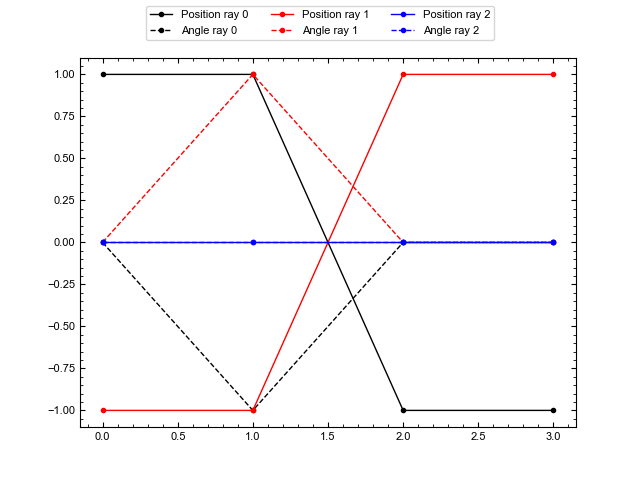

In [49]:
r0 = xp.array([[1,0],
               [-1,0],
               [0,0]])

ri = section1.propogate_ray(r0,
                            z=None#20
                           )
print('ri',ri.shape)

cs = ['k','r','b']
fig, ax = plt.subplots()
# for ele in section1.elements:
#     if ele.kind != 'drift': ax.axvline(ele.position, ls=':')

for i, path in enumerate(ri):
    ax.plot(path[...,0], ls='-',  c=cs[i], marker='.', label=f'Position ray {i}')
    ax.plot(path[...,1], ls='--', c=cs[i], marker='.', label=f'Angle ray {i}')
fig.legend(ncols=3, loc='upper center')


# Single elements

## Thin lens then manual Drift

In [10]:
from rayTEM.elements import Lens1D, Drift1D

In [11]:
lens = Lens1D(name='ThinLens', length=0, strength=1)
drift = Drift1D(length=2.)

lens, drift

,name,kind,length,strength,calibration
0,ThinLens,Thin Lens,0,1,None


,name,kind,length,strength,calibration
0,,drift,2.0,0,1


(, )

In [12]:
r0 = xp.array([[1,0],
               [-1,0],
               [0,0]])
print('r0',r0.shape)

r0 (3, 2)


c:\users\e81\documents\github\raytem\rayTEM\elements.py:120: SyntaxWarning: invalid escape sequence '\s'
  """Transfer matrix for ray propogation.
c:\users\e81\documents\github\raytem\rayTEM\elements.py:220: SyntaxWarning: invalid escape sequence '\s'
  The homogenous equaiton of motion approximation leads to a linear solution of $u"+k(s)u=0$ given as $u(s)=C(s)u_0+S(s)u_0', where s is the distance traveled (~z for small u').
c:\users\e81\documents\github\raytem\rayTEM\elements.py:313: SyntaxWarning: invalid escape sequence '\e'
  $$
c:\users\e81\documents\github\raytem\rayTEM\elements.py:399: SyntaxWarning: invalid escape sequence '\e'
  $$


r_lens: (3, 1, 4)
[[ 1. -1.  0.  0.]
 [-1.  1.  0.  0.]
 [ 0.  0.  0.  0.]]
ri_drift:  (3, 20, 4)


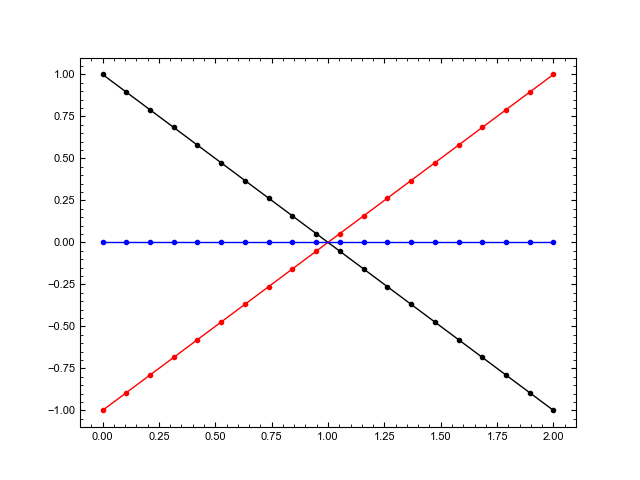

In [50]:
ri = lens.propogate_ray(r0)#, z=20)
print('r_lens:',ri.shape)
print(ri.squeeze())

z = 20#xp.arange(0,2)
ri2 = drift.propogate_ray(ri[:,-1], z=z, spectral_included=True)
print('ri_drift: ',ri2.shape)

fig, ax = plt.subplots()
for path in ri2[...,0]:
    ax.plot(xp.linspace(0,drift.length, z), path, ls='-', marker='.')

## Quad

In [1]:
from rayTEM.elements import Quadripole1D

In [4]:
quad = Quadripole1D(name='Quad',# poles=4,
                     length=10,
                     strength=0.2)
quad

,name,kind,length,strength,calibration
0,Quad,Quad,10,0.2,None


In [7]:
r0 = xp.array([[1,-1],
               [-1,1],
               [0,0]])
print('r0',r0.shape)

r0 (3, 2)


ri (3, 20, 2)


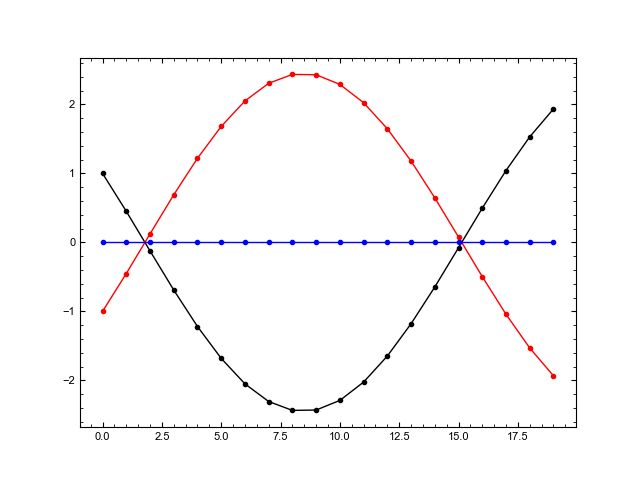

In [8]:
ri = quad.propogate_ray(r0, z=20)
print('ri',ri.shape)

fig, ax = plt.subplots()
for path, s in zip(ri[...,0], r0[...,0]):
    ax.plot(path, ls='-', marker='.')